In [ ]:
# Necessary imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, BatchNormalization, MaxPooling2D,
    GlobalAveragePooling2D, Dense, Dropout
)

import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import kagglehub

# Download latest version
dataset_path = kagglehub.dataset_download("kayvanshah/eye-dataset")

print("Path to dataset files:", dataset_path)

Using Colab cache for faster access to the 'eye-dataset' dataset.
Path to dataset files: /kaggle/input/eye-dataset


In [ ]:
# List folders/files in dataset root
print("Contents of dataset directory:")
for item in os.listdir(dataset_path):
  print(item)
  for item2 in os.listdir(dataset_path + "/" + item):
    print(item2)

Contents of dataset directory:
Eye dataset
forward_look
close_look
right_look
left_look


In [ ]:
data_dir = os.path.join(dataset_path,"Eye dataset")

categories = ['forward_look', 'close_look', 'right_look', 'left_look']
Categories_path_list=[]



In [ ]:
for category in categories:
    category_path = os.path.join(data_dir, category)
    Categories_path_list.append(category_path)

    print(f"\nReading from: {category_path}")

    # Make sure folder exists first
    if not os.path.isdir(category_path):
        print(f"Folder not found: {category_path}")
        continue

    for img_name in os.listdir(category_path):
        img_path = os.path.join(category_path, img_name)

        # Load one image for demonstration
        img_array = cv2.imread(img_path)

        if img_array is not None:
            print(f"Loaded image: {img_name}, shape: {img_array.shape}")
            # do your processing here
            break



Reading from: /kaggle/input/eye-dataset/Eye dataset/forward_look
Loaded image: forward_look (3293).png, shape: (119, 119, 3)

Reading from: /kaggle/input/eye-dataset/Eye dataset/close_look
Loaded image: eye_closed(2415).png, shape: (108, 108, 3)

Reading from: /kaggle/input/eye-dataset/Eye dataset/right_look
Loaded image: right_(906).png, shape: (104, 104, 3)

Reading from: /kaggle/input/eye-dataset/Eye dataset/left_look
Loaded image: left_(1894).png, shape: (103, 103, 3)


# Applying CNN Model

In [ ]:


model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), padding='same',
                 activation='relu', input_shape=(128,128,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Block 2
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Block 3
model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Block 4
model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Replace Flatten
model.add(Flatten())
# Dense layers
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(4, activation='softmax'))


from tensorflow.keras.optimizers import SGD

model.compile(optimizer="adam", loss='categorical_crossentropy',
                   metrics= ['accuracy',keras.metrics.Precision(),
                             keras.metrics.Recall(),
                             keras.metrics.SpecificityAtSensitivity(0.5),
                             keras.metrics.SensitivityAtSpecificity(0.5)])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.15,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Validation / Test Generator

test_val_gen = ImageDataGenerator(
    rescale=1./255
)

# -------- Training Data --------
train = train_gen.flow_from_directory(
    data_dir,
    target_size=(128,128),
    batch_size=32,
    color_mode="grayscale",
    class_mode="categorical",
    subset="training",
    shuffle=True
)

# -------- Validation Data --------
val = train_gen.flow_from_directory(
    data_dir,
    target_size=(128,128),
    batch_size=32,
    color_mode="grayscale",
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

# -------- Test Data (Independent) --------
test = test_val_gen.flow_from_directory(
    data_dir,
    target_size=(128,128),
    batch_size=32,
    color_mode="grayscale",
    class_mode="categorical",
    shuffle=False
)


Found 12208 images belonging to 4 classes.
Found 2152 images belonging to 4 classes.
Found 14360 images belonging to 4 classes.


In [ ]:
# Stop training if loss doesn't keep decreasing.
# Using EarlyStopping Callback
model1_es = EarlyStopping(monitor = 'val_loss', min_delta = 1e-11, patience = 10, verbose = 1)
# Using ReduceLROnPlateau Callback (According to learning rate)
model1_rlr = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.2, patience = 6, verbose = 1)

# Automatically saves the best weights of the model, based on best val_accuracy
model1_mcp = ModelCheckpoint(filepath = 'model_1_CNN.keras', monitor = 'val_accuracy',
                      save_best_only = True, verbose = 1)

In [ ]:
# Fiting the model.
history1 = model.fit(train, epochs=150, validation_data=val,
                     callbacks=[model1_es, model1_rlr, model1_mcp])


Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.4687 - loss: 3.1559 - precision_3: 0.5437 - recall_3: 0.3553 - sensitivity_at_specificity_3: 0.8049 - specificity_at_sensitivity_3: 0.8021
Epoch 1: val_accuracy improved from -inf to 0.38058, saving model to model_1_CNN.keras
382/382 ━━━━━━━━━━━━━━━━━━━━ 71s 157ms/step - accuracy: 0.4688 - loss: 3.1520 - precision_3: 0.5440 - recall_3: 0.3552 - sensitivity_at_specificity_3: 0.8051 - specificity_at_sensitivity_3: 0.8022 - val_accuracy: 0.3806 - val_loss: 2.7076 - val_precision_3: 0.3809 - val_recall_3: 0.3360 - val_sensitivity_at_specificity_3: 0.7593 - val_specificity_at_sensitivity_3: 0.7282 - learning_rate: 0.0010
Epoch 2/150
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.5449 - loss: 0.8870 - precision_3: 0.7329 - recall_3: 0.3579 - sensitivity_at_specificity_3: 0.9716 - specificity_at_sensitivity_3: 0.8913
Epoch 2: val_accuracy improved from 0.38058 to 0.52138, saving model to model_1_CNN.keras
382/382 ━━━━━━━━━━━━━━

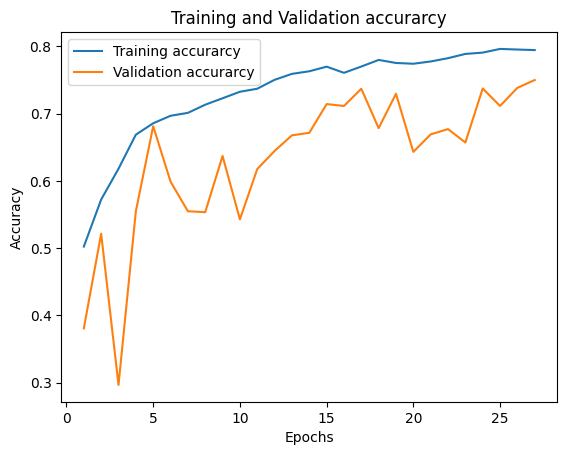

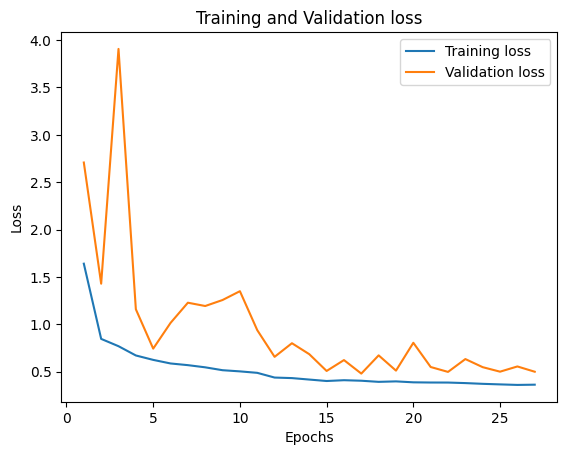

In [ ]:
acc = history1.history['accuracy']
val_acc = history1.history['val_accuracy']
loss = history1.history['loss']
val_loss = history1.history['val_loss']
epochs = range(1, len(acc) + 1)

#Train and validation accuracy
plt.plot(epochs, acc, label='Training accurarcy')
plt.plot(epochs, val_acc, label='Validation accurarcy')
plt.title('Training and Validation accurarcy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.figure()
#Train and validation loss
plt.plot(epochs, loss,  label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

In [ ]:
# # load best model

# from keras.models import load_model

# # Load the best model
# model = load_model('best_model.keras')

In [ ]:
model.evaluate(test)

449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - accuracy: 0.9452 - loss: 0.1850 - precision_3: 0.9550 - recall_3: 0.9428 - sensitivity_at_specificity_3: 0.9943 - specificity_at_sensitivity_3: 1.0000


[0.3360598087310791,
 0.813997209072113,
 0.821506917476654,
 0.8086351156234741,
 0.9994661211967468,
 0.9988161325454712]

In [ ]:
from tqdm import tqdm
import numpy as np
y_test = []
y_test_int = []
for i in tqdm(range(len(test))):
    y_test += test[i][1].tolist() # return onehot encoding
    y_test_int += test[i][1].argmax(axis=1).tolist()  #numbers from 0 t0 3

y_test = np.array(y_test)
y_test_int = np.array(y_test_int)

100%|██████████| 449/449 [00:36<00:00, 12.43it/s]


449/449 ━━━━━━━━━━━━━━━━━━━━ 26s 53ms/step
Accuracy is:  0.8139972144846797


<Axes: >

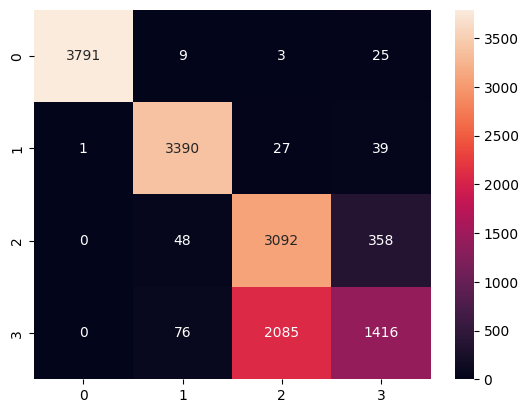

In [ ]:
#Creating a confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

y_pred_test = model.predict(test, verbose=1)
y_pred_test_int = y_pred_test.argmax(axis=1)


ac = accuracy_score(y_test_int, y_pred_test_int)
print('Accuracy is: ',ac)
cm = confusion_matrix(y_test_int, y_pred_test_int)
sn.heatmap(cm,annot=True,fmt="d")

In [ ]:
from sklearn.metrics import classification_report
target_names = ['forward_look', 'close_look', 'right_look', 'left_look']
print(classification_report(y_test_int, y_pred_test_int, target_names=target_names, digits=4))

              precision    recall  f1-score   support

forward_look     0.9997    0.9903    0.9950      3828
  close_look     0.9622    0.9806    0.9713      3457
  right_look     0.5938    0.8839    0.7104      3498
   left_look     0.7704    0.3959    0.5230      3577

    accuracy                         0.8140     14360
   macro avg     0.8316    0.8127    0.7999     14360
weighted avg     0.8347    0.8140    0.8024     14360

